<span style="color:pink; font-size:20px;">File to get plots for Ergotropic Changes vs Correlation Measures of Initial States.</span>

In [ ]:
# Import necessary libraries and modules
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from state_gen import generate_state
from energy import energy, passive_energy_g, passive_energy_l, ergotropy_gap, global_ergo, local_ergo
from local_to import sho_ham, LTO_step, gibbs_states
from unitary import deg_unitary
from lin_alg import negativity, partial_trace, vn_entropy, rel_entropy, passive_state, mutual_info, purity
np.set_printoptions(linewidth=np.inf, precision=4, suppress=True)

def fmt(M): return np.array2string(M, precision=4, suppress_small=True, floatmode='fixed', max_line_width=80)

In [ ]:
# Default Parameters
beta_a=1.0
beta_b=0.8
bath_dim_a = bath_dim_b = 6
sys_dim_a = sys_dim_b = 3
omega_a = omega_b = 0.1
w1=0.1
w2=0.2

In [ ]:
# --- Simulation for many initial states and fixed/random unitary ---

def simulate_fixed_unitary_mi(uni_type = "fixed", num_states=100, n_samples=200):

    Rg_lto_list, Rl_lto_list = [], []
    gbound_list_states, lbound_list_states = [], []
    mi_list, R_gap_ini, R_gap_sigma = [], [], []
    purity_list = []

    # ----- Baths state (precompute once) -----
    gamma_a, gamma_b = gibbs_states(bath_dim_a, bath_dim_b, beta_a, beta_b, omega_a, omega_b)
    gibbs_a, gibbs_b = gibbs_states(sys_dim_a, sys_dim_b, beta_a, beta_b, w1, w2)

    Hs1 = sho_ham(sys_dim_a, w1)
    Hs2 = sho_ham(sys_dim_b, w2)
    Hb1 = sho_ham(bath_dim_a, omega_a)
    Hb2 = sho_ham(bath_dim_b, omega_b)

    def compute_vals(rho12, Ua, Ub):
        sigma, _, _ = LTO_step(rho12, gamma_a, gamma_b, Ua, Ub)

        # ---- observables ----
        E_sigma = energy(sigma, sys_dim_a, sys_dim_b, w1, w2)
        Rg = E_sigma - passive_energy_g(sigma, sys_dim_a, sys_dim_b, w1, w2)
        Rl = E_sigma - passive_energy_l(sigma, sys_dim_a, sys_dim_b, w1, w2)

        # ---- reduced states ----
        sigma1 = partial_trace(sigma, sys_dim_a, sys_dim_b, sys=1)
        sigma2 = partial_trace(sigma, sys_dim_a, sys_dim_b, sys=0)

        # ---- global correction term ----
        local_term = (1/beta_a) * (vn_entropy(sigma1) - vn_entropy(rho1)) + (1/beta_b) * (vn_entropy(sigma2) - vn_entropy(rho2))
        energy_term = - passive_energy_g(rho12, sys_dim_a, sys_dim_b, w1, w2) + passive_energy_g(sigma, sys_dim_a, sys_dim_b, w1, w2)
        bound_g = energy_term + local_term

        return Rg, Rl, Rg - Rl, bound_g

    if uni_type == "fixed":
        Ua = deg_unitary(Hs1, Hb1)
        Ub = deg_unitary(Hs2, Hb2)

    # ----- Sampling loop -----
    for i in tqdm(range(num_states), desc="State samples", leave=False):

        # ----- Initial state -----
        rho12 = generate_state(sys_dim_a*sys_dim_b)

        # ---- reduced states ----
        rho1 = partial_trace(rho12, sys_dim_a, sys_dim_b, sys=1)
        rho2 = partial_trace(rho12, sys_dim_a, sys_dim_b, sys=0)
        pass_rho_1 = passive_state(rho1)
        pass_rho_2 = passive_state(rho2)

        # ----- initial observables ----
        mi_list.append(mutual_info(rho12, sys_dim_a, sys_dim_b))

        Rg0 = global_ergo(rho12, sys_dim_a, sys_dim_b, w1, w2)
        Rl0 = local_ergo(rho12, sys_dim_a, sys_dim_b, w1, w2)
        R_gap0 = ergotropy_gap(rho12, sys_dim_a, sys_dim_b, w1, w2)

        # ---- local bound ----
        bound_l = rel_entropy(pass_rho_1, gibbs_a)/beta_a + rel_entropy(pass_rho_2, gibbs_b)/beta_b

        Rg_lto, Rl_lto, R_gap, gbound_list = [], [], [], []

        if uni_type == "random" or n_samples == "fixed": n_samples = 1

        for _ in range(n_samples):
            
            if uni_type != "fixed":
                Ua = deg_unitary(Hs1, Hb1)
                Ub = deg_unitary(Hs2, Hb2)
            
            Rg, Rl, Rgap, bound_g = compute_vals(rho12, Ua, Ub)
            Rg_lto.append(Rg)
            Rl_lto.append(Rl)
            R_gap.append(Rgap)
            gbound_list.append(bound_g)
            

        Rg_lto_list.append(max(Rg_lto) - Rg0)
        Rl_lto_list.append(max(Rl_lto) - Rl0)
        R_gap_ini.append(Rg0 - Rl0)
        R_gap_sigma.append(max(R_gap))
        gbound_list_states.append(max(gbound_list))
        lbound_list_states.append(bound_l)
        purity_list.append(purity(rho12))
        # print(purity(rho12))

    return (mi_list, gbound_list_states, lbound_list_states, Rg_lto_list, Rl_lto_list, R_gap_ini, R_gap_sigma, purity_list)
    

In [14]:
def plot_lto_results2(mi_list, gbound_list, lbound_list, Rg_lto, Rl_lto, R_gap_ini, R_gap_sigma, purity_list,
    # ── aesthetic controls ────────────────────────────────────────
    figsize        = (15, 12),
    marker_size    = 30,
    alpha          = 0.55,
    marker         = 'o',
    bound_marker   = '^',
    font_size      = 11,
    title_size     = 12,
    legend_size    = 9,
    tick_size      = 9,
    linewidth      = 0.4,       # scatter edge linewidth
    dpi            = 120,
    palette        = None,
    suptitle       = None,
    save_path      = None,
):
    """
    2×2 professional visualization of LTO ergotropy behaviour vs negativity.

    Parameters
    ----------
    neg_list      : negativity of initial states
    mi_list       : mutual information of initial states
    gbound_list   : global ergotropy bound per state
    lbound_list   : local ergotropy bound per state
    Rg_lto        : ΔRg = Rg(σ) - Rg(ρ) per state
    Rl_lto        : ΔRl = Rl(σ) - Rl(ρ) per state
    R_gap_ini     : initial ergotropy gap Rl - Rg per state
    R_gap_sigma   : post-LTO ergotropy gap per state
    """

    # ── default palette ───────────────────────────────────────────
    if palette is None:
        palette = {
            'global'  : '#2196F3',   # blue
            'local'   : '#4CAF50',   # green
            'gap_ini' : '#9E9E9E',   # grey
            'gap_sig' : '#FF5722',   # deep orange
            'gbound'  : "#F62415",   # red
            'lbound'  : '#9C27B0',   # purple
        }

    # ── convert to arrays ─────────────────────────────────────────
    mi         = np.array(mi_list)
    Rg          = np.array(Rg_lto)
    Rl          = np.array(Rl_lto)
    gap_ini     = np.array(R_gap_ini)
    gap_sig     = np.array(R_gap_sigma)
    gbound      = np.array(gbound_list)
    lbound      = np.array(lbound_list)
    purity     = np.array(purity_list)

    # ── shared scatter kwargs ─────────────────────────────────────
    def skw(color, marker=marker):
        return dict(s=marker_size, color=color, alpha=alpha,
                    marker=marker, linewidths=linewidth,
                    edgecolors='white', zorder=3)

    def bkw(color):   # bound marker kwargs
        return dict(s=marker_size*0.8, color=color, alpha=alpha*0.85,
                    marker=bound_marker, linewidths=linewidth,
                    edgecolors='white', zorder=4)

    # ── figure ────────────────────────────────────────────────────
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axs = plt.subplots(3, 2, figsize=(figsize[0], figsize[1]*1.5), dpi=dpi)
    # axs[2, 1].axis('off')

    if suptitle:
        fig.suptitle(suptitle, fontsize=title_size + 1, fontweight='bold', y=1.01)

    # helper: shared axis styling
    def style(ax, xlabel, ylabel, title):
        ax.set_xlabel(xlabel,  fontsize=font_size)
        ax.set_ylabel(ylabel,  fontsize=font_size)
        ax.set_title(title,    fontsize=title_size, fontweight='semibold', pad=8)
        ax.tick_params(labelsize=tick_size)
        ax.axhline(0, color='#BDBDBD', linewidth=0.9,
                   linestyle='--', zorder=1)
        ax.legend(fontsize=legend_size, frameon=True,
                  framealpha=0.85, edgecolor='#E0E0E0')

    # ── Panel (0,0): ΔRg vs mutual information ───────────────────────────
    ax = axs[0, 0]
    ax.scatter(mi, Rg,     label=r"$\Delta R_g$",       **skw(palette['global']))
    ax.scatter(mi, gbound, label=r"Global bound (exp.)", **bkw(palette['gbound']))
    style(ax, xlabel=r"Mutual Information $\mathcal{I}$", ylabel=r"$\Delta R_{\rm global}$", title=r"Global Ergotropy Change vs $\mathcal{I}$")

    # ── Panel (0,1): ΔRl vs mutual information ───────────────────────────
    ax = axs[0, 1]
    ax.scatter(mi, Rl,     label=r"$\Delta R_l$",   **skw(palette['local']))
    ax.scatter(mi, lbound, label=r"Local bound",     **bkw(palette['lbound']))
    style(ax, xlabel=r"Mutual Information $\mathcal{I}$", ylabel=r"$\Delta R_{\rm local}$", title=r"Local Ergotropy Change vs $\mathcal{I}$")

    # ── Panel (1,0): ergotropy gap vs mutual information ─────────────────
    ax = axs[1, 0]
    ax.scatter(mi, gap_ini, label=r"$R_g - R_l$ (initial)",   **skw(palette['gap_ini']))
    ax.scatter(mi, gap_sig, label=r"$R_g - R_l$ (after LTO)", **skw(palette['gap_sig']))
    style(ax, xlabel=r"Mutual Information $\mathcal{I}$", ylabel=r"$R_g - R_l$", title=r"Ergotropy Gap vs $\mathcal{I}$")

    # ── Panel (1,1): ΔRg vs ΔRl with mi coloring ──────────────
    ax = axs[1, 1]
    sc2 = ax.scatter(Rg, Rl, c=mi, cmap='viridis', s=marker_size, alpha=alpha, linewidths=linewidth, edgecolors='white', zorder=3)
    cbar2 = fig.colorbar(sc2, ax=ax, pad=0.02)
    cbar2.set_label(r"Mutual Information $\mathcal{I}$", fontsize=font_size - 1)
    cbar2.ax.tick_params(labelsize=tick_size - 1)

    # diagonal reference ΔRg = ΔRl
    lims2 = [min(Rg.min(), Rl.min()) - 0.01, max(Rg.max(), Rl.max()) + 0.01]
    ax.plot(lims2, lims2, color='#BDBDBD', linewidth=0.9, linestyle='--', zorder=1, label=r"$\Delta R_g = \Delta R_l$")

    # vertical line at x=0 and horizontal at y=0
    ax.axvline(0, color='#BDBDBD', linewidth=0.9, linestyle=':', zorder=1)
    ax.set_xlim(lims2);  ax.set_ylim(lims2)
    style(ax, xlabel=r"$\Delta R_{\rm global}$", ylabel=r"$\Delta R_{\rm local}$", title=r"$\Delta R_{\rm global}$ vs $\Delta R_{\rm local}$")

    # ── Panel (2,0): ΔRg vs purity ───────────────────────────
    ax = axs[2, 0]
    ax.scatter(purity, Rg,     label=r"$\Delta R_g$",   **skw(palette['global']))
    ax.scatter(purity, gbound, label=r"Global bound",     **bkw(palette['gbound']))
    style(ax, xlabel=r"Purity", ylabel=r"$\Delta R_{\rm global}$", title=r"Global Ergotropy Change vs Purity")

    # ── Panel (2,1): ΔRl vs purity ───────────────────────────
    ax = axs[2, 1]
    ax.scatter(purity, Rl,     label=r"$\Delta R_l$",   **skw(palette['local']))
    ax.scatter(purity, lbound, label=r"Local bound",     **bkw(palette['lbound']))
    style(ax, xlabel=r"Purity", ylabel=r"$\Delta R_{\rm local}$", title=r"Local Ergotropy Change vs Purity")

    # ── layout and save ───────────────────────────────────────────
    fig.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=dpi)
        print(f"  Saved → {save_path}")

    plt.show()

In [ ]:
# Initialize parameters for harmonic oscillator simulation

# Inverse temperatures and dimensions
beta_a=1.0
beta_b=0.8
bath_dim_a = bath_dim_b = 10
sys_dim_a = sys_dim_b = 4

# Hamiltonian parameters
omega_a = omega_b = 0.1
w1=0.1
w2=0.2

In [ ]:
(mi_list, gbound_list_states, lbound_list_states, Rg_lto_list, 
 Rl_lto_list, R_gap_ini, R_gap_sigma, purity_list) = simulate_fixed_unitary_mi(uni_type="fixed", num_states=50)

Degenerate blocks: ['E=0.1000: [1, 10]', 'E=0.2000: [2, 11, 20]', 'E=0.3000: [3, 12, 21, 30]', 'E=0.4000: [4, 13, 22, 31]', 'E=0.5000: [5, 14, 23, 32]', 'E=0.6000: [6, 15, 24, 33]', 'E=0.7000: [7, 16, 25, 34]', 'E=0.8000: [8, 17, 26, 35]', 'E=0.9000: [9, 18, 27, 36]', 'E=1.0000: [19, 28, 37]', 'E=1.1000: [29, 38]']
Degenerate blocks: ['E=0.2000: [2, 10]', 'E=0.3000: [3, 11]', 'E=0.4000: [4, 12, 20]', 'E=0.5000: [5, 13, 21]', 'E=0.6000: [6, 14, 22, 30]', 'E=0.7000: [7, 15, 23, 31]', 'E=0.8000: [8, 16, 24, 32]', 'E=0.9000: [9, 17, 25, 33]', 'E=1.0000: [18, 26, 34]', 'E=1.1000: [19, 27, 35]', 'E=1.2000: [28, 36]', 'E=1.3000: [29, 37]']


State samples:   0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

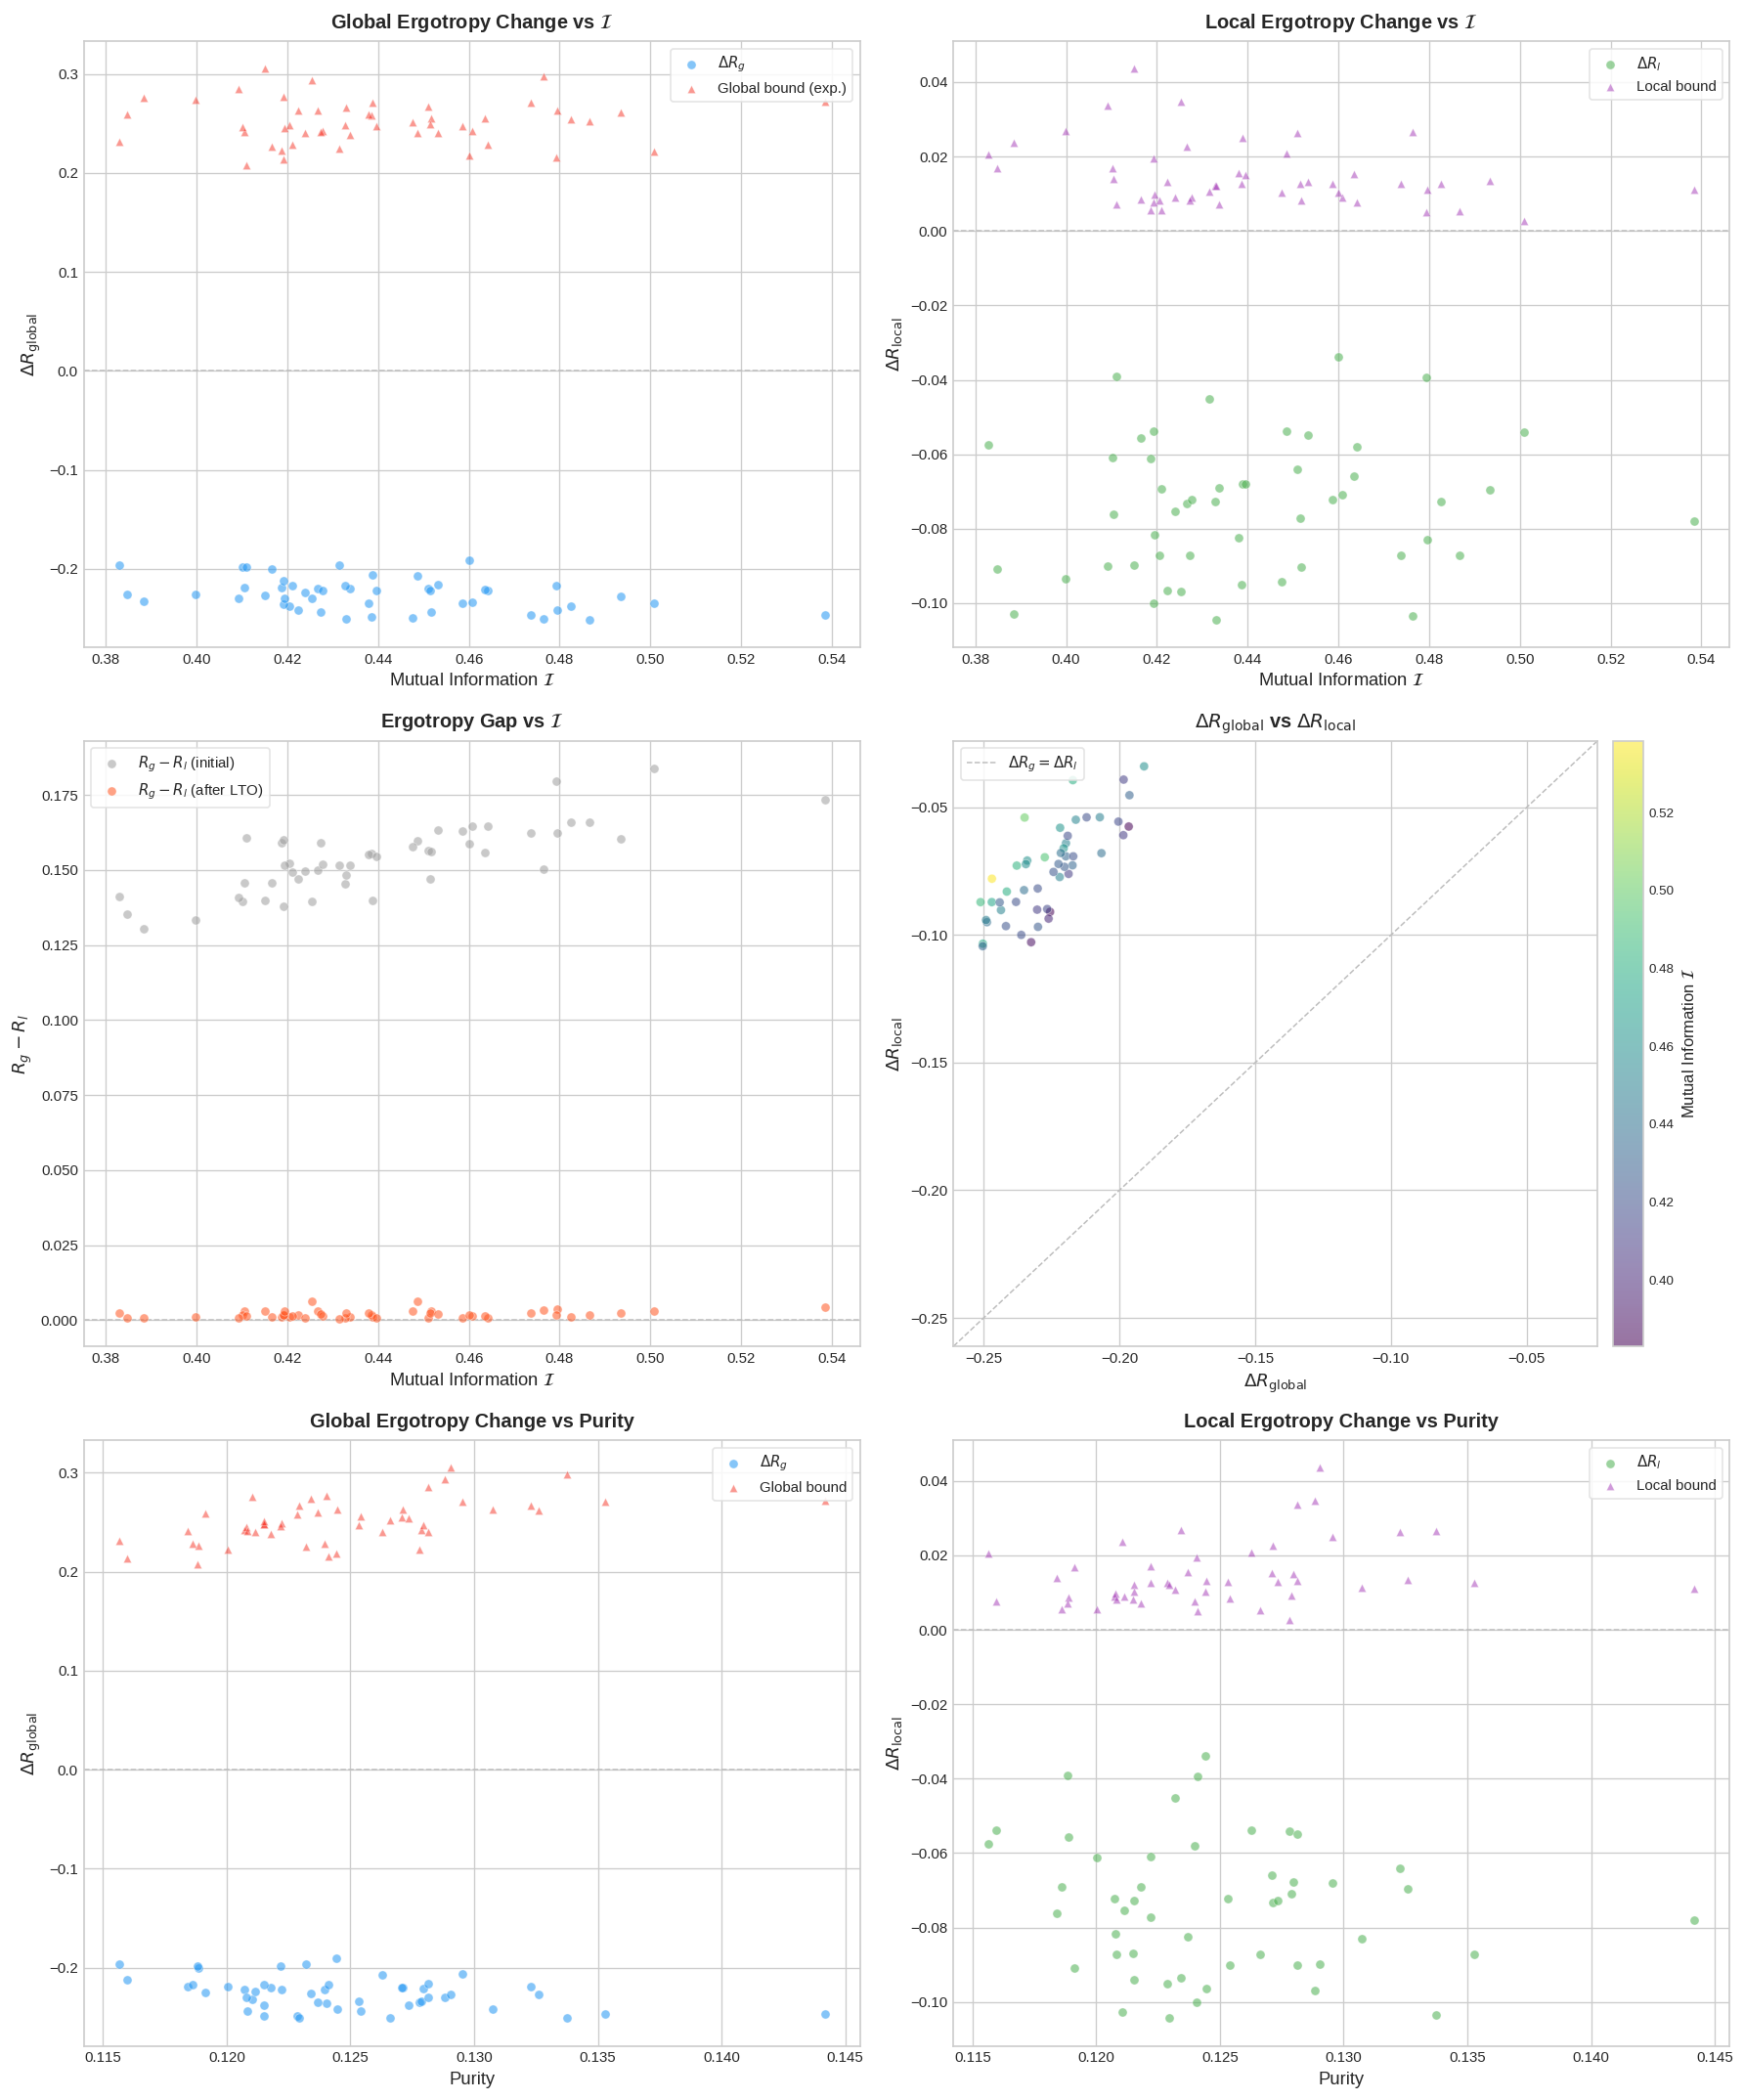

In [16]:
plot_lto_results2(mi_list, gbound_list_states, lbound_list_states, Rg_lto_list, Rl_lto_list, R_gap_ini, R_gap_sigma, purity_list)